<div class="alert alert-block alert-info">
<b>¡Hola! Galilea👋</b>

Mi nombre es Santiago. Un gusto acompañarte en este proyecto del Sprint 5.

Antes de empezar, te comparto cómo funciona la revisión:
<ul>
<li>Cuando encuentre un error, lo señalaré para que lo detectes y corrijas por tu cuenta.</li>
<li>Si en algún punto no logras resolver algo, en la siguiente iteración te daré una pista más concreta.</li>
<li>Por favor no muevas ni elimines mis comentarios. Puedes responder debajo usando un bloque de texto.</li>
</ul>

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>
Éxito. ✅
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>
Observación. No bloquea la aprobación.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>
Necesita ajustes antes de aprobar.
</div>

<div class="alert alert-block alert-warning">
<b>Review General. (Iteración 1)</b>

Antes de entrar en el detalle, quiero destacar todo lo que está muy bien.

El renombrado de eco es completo, la limpieza numérica produce valores correctos (18117.0 para Buenos Aires 2024), los filtros de 2024 son correctos, el groupby está sobre <code>traffic_2024</code>, el merge produce las 15 ciudades correctas, el boxplot tiene <code>showmeans=True</code>, el gráfico de barras usa <code>secondary_y</code> para manejar las dos escalas (mejor que la solución oficial), el CSV se exportó, la reflexión del Paso 6 es correcta y bien redactada, y el resumen ejecutivo (celda 45) es uno de los más completos que he visto en este proyecto — incluye correlación cuantitativa (0.283), valores concretos por ciudad y una recomendación de Bogotá muy bien fundamentada.

Hay <b>un único punto que corregir antes de aprobar</b>:
<ul>
<li>🔴 <b>Una columna de traffic quedó sin renombrar</b>: <code>TrafficIndexWeekAgo</code> sigue en PascalCase en la salida del rename.</li>
</ul>

</div>

<div class="alert alert-block alert-success">
<b>Review General. (Iteración 2)</b>

¡Hola, Galilea! Esta segunda iteración fue muy limpia — fuiste directa al punto.

El único bloqueante de la iteración 1 queda resuelto: el output de la celda 18 confirma que <b><code>traffic_index_week_ago</code></b> ahora está correctamente incluida en el rename. Las 12 columnas de traffic están en <code>snake_case</code> y coinciden exactamente con el solucionario. ✅

Aproveché para revisar también los puntos menores de la iteración anterior:

<ul>
<li>✅ <b>Reflexión Paso 4 enriquecida:</b> ahora dice "Ciudad de México con <b>2,833 minutos</b>, muy por encima de Tokio en 2do lugar". Exactamente lo que se pedía.</li>
<li>✅ <b>Merge correcto:</b> 15 ciudades latinoamericanas del año 2024, valores correctos (belo-horizonte, bogota, brasilia, buenos-aires...).</li>
<li>✅ <b>Resumen ejecutivo excelente:</b> cobertura de 15 ciudades y 7 países, metodología con INNER JOIN explicado, correlación cuantitativa (0.283), Mexico City y Montevideo con valores concretos, Bogotá como recomendación fundamentada comparativamente. Sin lenguaje causal. Es uno de los mejores resúmenes que he visto en este proyecto.</li>
</ul>

Solo te dejo una observación menor (🟡) sobre el orden de ejecución.

</div>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [18]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [19]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv') #completa el código

In [20]:
traffic.head(5) # mostrar las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [21]:
eco.head(5)
 # mostrar las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.




---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [22]:
traffic.info()
# Examinar la estructura de traffic

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo "object" pero deberían de  ser de tipo DATETIME

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
La observación principal es correcta: <code>UpdateTimeUTC</code> y <code>UpdateTimeUTCWeekAgo</code> son tipo <code>object</code> y deben convertirse a <code>datetime</code>. ✅ Solo un detalle: la celda aún tiene dos viñetas vacías debajo. Puedes eliminarlas para que quede limpia.
</div>

In [23]:
eco.info() 
# Examinar la estructura de eco

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, ˋPM2.5ˋ, Y ˋPopulationˋ son de tipo object pero deberían de ser de tipo FLOAT

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
EDA de eco correcto: identificas las cuatro columnas con tipo <code>object</code> que deben convertirse a <code>float</code>. ✅
</div>

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [24]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={'Country': 'country', 'City': 'city', 'UpdateTimeUTC': 'update_time_utc', 'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago', 
                                  'JamsDelay': 'jams_delay', 'TrafficIndexLive': 'traffic_index_live', 'JamsLengthInKms': 'jams_length_kms', 'JamsCount': 'jams_count', 
                                   'MinsDelay': 'mins_delay', 'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins', 
                                  'TravelTimeHistoricPer10KmsMins': 'travel_time_hist_per_10kms_mins', 'TrafficIndexWeekAgo': 'traffic_index_week_ago' })
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>
Confirmado: las 12 columnas de traffic están en <code>snake_case</code> correcto, incluyendo <code>traffic_index_week_ago</code>. Coincide exactamente con el solucionario. ✅
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b>
El renombrado de traffic está casi completo, pero el output muestra que <b><code>TrafficIndexWeekAgo</code> no fue incluida</b> y sigue en PascalCase:
<pre>
Index([..., 'jams_count', <b>'TrafficIndexWeekAgo'</b>, 'update_time_utc_week_ago', ...])
</pre>
Las otras 11 columnas están perfectas. Solo falta agregar esta línea al diccionario:
<pre>'TrafficIndexWeekAgo': 'traffic_index_week_ago'</pre>
</div>

In [25]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco = eco.rename(columns={'Country': 'country', 'Year': 'year', 'City':'city', 'UpdateTimeUTC': 'update_time_utc', 
                          'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago', 'City GDP/capita': 'city_gdp_capita', 
                          'Unemployment %': 'unemployment_pct', 'Population (M)': 'population_m', 'PM2.5 (μg/m³)': 'pm25' })
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Renombrado de eco completo con los nombres exactos del solucionario: <code>city_gdp_capita</code>, <code>unemployment_pct</code>, <code>pm25</code>, <code>population_m</code>. ✅
</div>


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [26]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce') #tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce') #tu código aquí

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [27]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = (
    eco['city_gdp_capita']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
    
)


eco['unemployment_pct'] = (
    eco['unemployment_pct']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
    .astype(float)
)

eco['population_m'] = (
    eco['population_m']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.strip()
    .astype(float)
)

eco['pm25'] = (
    eco['pm25']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float))

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1_000_000

# verificar el cambio
eco.info()
eco.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0
3,2023,brasilia,Brazil,15999.0,8.3,13.5,4.7,4700000.0
4,2023,salvador,Brazil,8761.0,13.1,16.0,3.9,3900000.0
5,2023,fortaleza,Brazil,838.0,12.5,15.4,4.2,4200000.0
6,2023,belo-horizonte,Brazil,10951.0,10.1,17.5,6.0,6000000.0
7,2023,curitiba,Brazil,12189.0,8.8,14.2,3.6,3600000.0
8,2023,recife,Brazil,9047.0,11.8,16.5,4.1,4100000.0
9,2023,porto-alegre,Brazil,11618.0,9.2,14.9,4.3,4300000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Limpieza numérica correcta: city_gdp_capita BA 2024 = <b>18117.0</b> ✅, unemployment_pct = 7.2 ✅, pm25 convertida a float ✅ (la solución no la convierte — buen detalle extra), population calculada en unidades absolutas ✅.
</div>


---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [28]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic["update_time_utc"].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [29]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Filtros correctos: <code>traffic_2024</code> y <code>eco_2024</code> con <code>year==2024</code> y <code>.copy()</code>. ✅
</div>


---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [30]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (
    traffic_2024.groupby(['city', 'country', 'year'])[
        [
            "jams_delay", 
            "traffic_index_live", 
            "jams_length_kms", 
            "jams_count", 
            "mins_delay", 
            "travel_time_live_per_10kms_mins", 
            "travel_time_hist_per_10kms_mins"
        ]
    ]
    .mean()
    .reset_index()
    )

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Groupby correcto sobre <code>traffic_2024</code> con promedio. Solo año 2024. ✅
</div>

### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas

**Me sorprendió observar que la ciudad con mayor retraso promedio por tráfico fue Mexico City, seguida por Tokyo y New York. Aunque esperaba encontrar ciudades latinoamericanas entre las más congestionadas, no imaginaba que Ciudad de México ocuparía el primer lugar. Los resultados muestran que la congestión vehicular es un problema compartido por ciudades de distintas regiones del mundo.**

In [17]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending = False)


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es la Ciudad de México con 2,833 minutos; muy por encima de los valores mostrados por Tokio, quien se encuentra en 2do lugar

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>
Ciudad de México con el valor exacto (2,833 min) y la comparación con Tokio. ✅ Eso convierte la observación de descriptiva a analítica.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
Respuesta correcta: Ciudad de México. ✅ Para enriquecerla, añade el valor numérico (<b>~2833 minutos</b>) y contexto comparativo — por ejemplo, que casi duplica a Tokyo en segundo lugar (~2152 min).
</div>


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [31]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[ left_cols ].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner') # tu código aquí

# Mostrar las primeras 5 filas

merged.info()
merged.describe()
merged.isna().sum()
merged.head(5)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   city                             15 non-null     object 
 1   country                          15 non-null     object 
 2   year                             15 non-null     int64  
 3   jams_delay                       15 non-null     float64
 4   traffic_index_live               15 non-null     float64
 5   jams_length_kms                  15 non-null     float64
 6   jams_count                       15 non-null     float64
 7   mins_delay                       15 non-null     float64
 8   travel_time_live_per_10kms_mins  15 non-null     float64
 9   travel_time_hist_per_10kms_mins  15 non-null     float64
 10  city_gdp_capita                  15 non-null     float64
 11  unemployment_pct                 15 non-null     float64
 12  pm25                    

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3700000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Merge correcto: inner join, 15 ciudades latinoamericanas del año 2024. ✅
</div>


---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

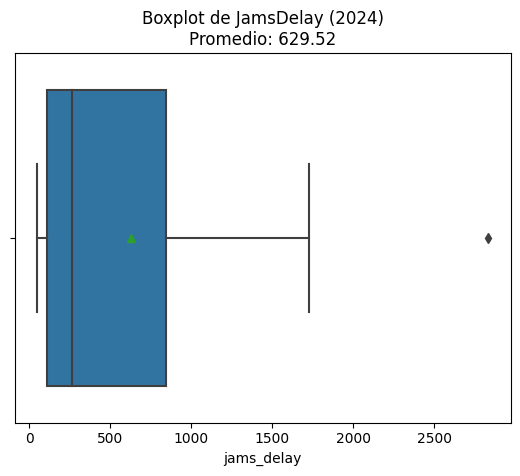

In [32]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
sns.boxplot(data=merged, x= 'jams_delay', showmeans= True)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Boxplot con <code>showmeans=True</code> y promedio en el título. ✅
</div>

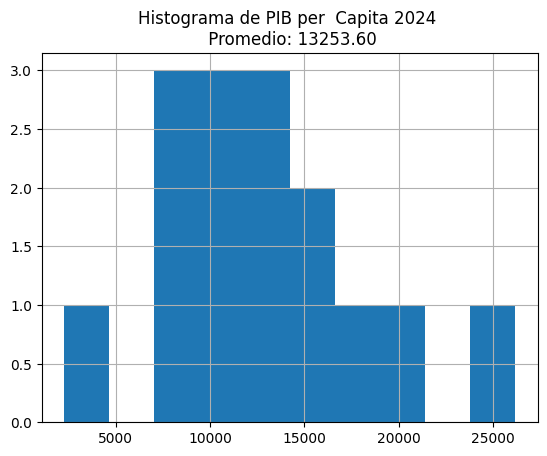

In [20]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
sns.histplot(data=merged, x='city_gdp_capita', kde=True)

#Obtener el promedio
mean_val= merged['city_gdp_capita'].mean()
plt.title(f'Histograma de PIB per  Capita 2024 \n Promedio: {mean_val:.2f}')
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
El histograma funciona. Para el próximo proyecto, considera <code>sns.histplot(data=merged, x='city_gdp_capita', kde=True)</code> en lugar de <code>.hist()</code> — obtienes la curva de densidad y el estilo queda consistente con seaborn.
</div>

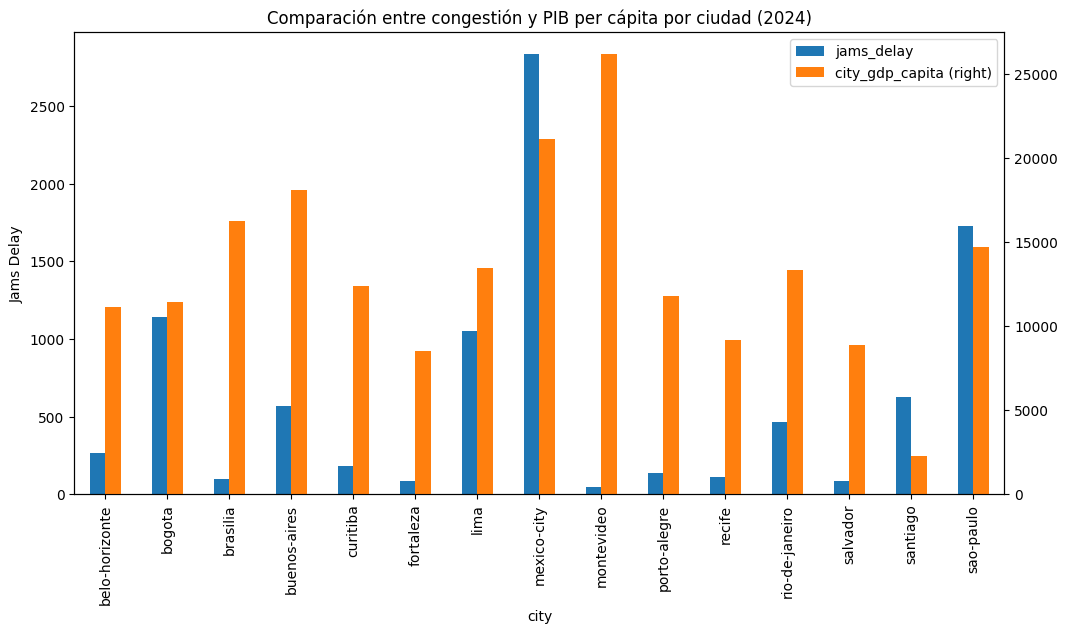

In [24]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
ax = merged.plot(
    x='city',
    y=['jams_delay', 'city_gdp_capita'],
    kind='bar',
    secondary_y='city_gdp_capita',
    figsize=(12,6)
)

plt.title('Comparación entre congestión y PIB per cápita por ciudad (2024)')
plt.xlabel('Ciudad')
ax.set_ylabel('Jams Delay')

plt.xticks(rotation=90)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Gráfico de barras con <code>kind='bar'</code>, <code>secondary_y='city_gdp_capita'</code>, y <code>xticks(rotation=90)</code>. El eje secundario resuelve el problema de escala y va más allá de lo que pide la solución oficial. 👏 ✅
</div>

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios: **Al comparar jams_delay con city_gdp_capita por ciudad, no se observa una relación clara entre ambas variables. Algunas ciudades con PIB per cápita alto presentan baja congestión, mientras que otras con PIB menor muestran niveles de tráfico más elevados. Esto sugiere que el nivel económico de una ciudad no determina por sí solo su congestión vehicular, sino que también influyen otros factores urbanos y de movilidad.**

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Reflexión correcta y bien redactada: ausencia de relación clara, dos grupos opuestos identificados, lenguaje no causal apropiado ("sugiere que el nivel económico no determina por sí solo"). ✅
</div>


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [31]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

merged[['city','jams_delay','city_gdp_capita','unemployment_pct']].sort_values(['jams_delay','city_gdp_capita'],ascending=[False,True])

,city,jams_delay,city_gdp_capita,unemployment_pct
7,mexico-city,2833.057892,21111.0,3.2
14,sao-paulo,1729.189270,14703.0,8.5
1,bogota,1141.552364,11442.0,10.0
6,lima,1052.292789,13472.0,6.5
13,santiago,629.865318,2277.0,7.8
3,buenos-aires,571.089593,18117.0,7.2
11,rio-de-janeiro,466.064706,13349.0,9.2
0,belo-horizonte,263.047879,11124.0,9.5
4,curitiba,183.469274,12381.0,8.2
9,porto-alegre,139.382830,11801.0,8.7


Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?



---

# 🧾 Resumen ejecutivo

**Contexto & objetivo:**  
- El objetivo de este análisis fue explorar la relación entre la movilidad urbana y la productividad económica durante 2024, utilizando indicadores de congestión vehicular y tiempos de viaje provenientes de TomTom, junto con variables económicas de la OECD como PIB per cápita, desempleo y población.
- Las variables principales analizadas fueron jams_delay como indicador de congestión y city_gdp_capita como medida de productividad económica urbana.
- Comprender esta relación puede apoyar la priorización de inversiones en infraestructura y movilidad.

**Cobertura de datos:**  
- El análisis se realizó utilizando información correspondiente al año 2024.
- Tras la limpieza, agregación y unión de los datasets, el conjunto final quedó conformado por 15 ciudades pertenecientes a 7 países: Argentina, Brasil, Chile, Colombia, México, Perú y Uruguay.
- El dataset final integró indicadores de tráfico promedio por ciudad con variables económicas y demográficas.

**Metodología (alto nivel):**  
- Se realizó la limpieza y estandarización de los datos, incluyendo la conversión de fechas, corrección de formatos numéricos y adopción de nombres de columnas en formato snake_case.
- Posteriormente, los datos de tráfico fueron agregados a nivel ciudad-año mediante promedios de las principales métricas de movilidad. Finalmente, ambos conjuntos de datos fueron integrados mediante una unión tipo INNER JOIN utilizando las variables city y year.
- Para validar la información se utilizaron gráficos de distribución, boxplots e histogramas que permitieron detectar valores atípicos y evaluar tendencias generales.

**Hallazgos iniciales:**  
- Los resultados muestran una relación positiva débil entre congestión y PIB per cápita, con una correlación de aproximadamente 0.283.
- Esto indica que no existe una relación fuerte entre ambas variables; es decir, un mayor nivel de productividad económica no implica necesariamente una mayor congestión vehicular.
- Se identificó a Mexico City como el principal valor atípico del conjunto, registrando el mayor nivel de congestión (jams_delay = 2833.06) y uno de los PIB per cápita más altos (21111).
- También destacan Sao Paulo, Bogotá y Lima por sus elevados niveles de congestión.
- Por otro lado, Montevideo presenta el PIB per cápita más alto (26176) y el menor nivel de congestión (50.20), representando un caso opuesto que podría estudiarse con mayor profundidad.

**Recomendaciones**  
- Los resultados sugieren que la congestión urbana está influenciada por factores adicionales al desempeño económico, como la infraestructura vial, la densidad poblacional y la planificación urbana.
- Considerando simultáneamente altos niveles de congestión y niveles de productividad económica relativamente más bajos, Bogotá aparece como la ciudad que mejor cumple el criterio para priorizar inversiones en infraestructura de transporte.
- Aunque Mexico City presenta la mayor congestión, también posee uno de los PIB per cápita más elevados del grupo analizado. En contraste, Bogotá combina una congestión considerablemente alta (1141.55) con un PIB per cápita inferior al de varias ciudades comparables (11442), lo que la convierte en una candidata relevante para intervenciones orientadas a mejorar la movilidad y la productividad.
- Asimismo, se recomienda realizar análisis adicionales incorporando variables como densidad poblacional, extensión urbana y calidad del transporte público para comprender mejor los factores que explican la congestión entre ciudades.


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
El resumen ejecutivo (celda 45) tiene las cinco secciones con contenido sustancial:
<ul>
<li>✅ Contexto con variables clave y relevancia para decisiones.</li>
<li>✅ Cobertura precisa: 15 ciudades, 7 países, año 2024.</li>
<li>✅ Metodología: limpieza, INNER JOIN, aggregación, visualización.</li>
<li>✅ Hallazgos con datos concretos: correlación 0.283, CDMX (2833, PIB 21111), Montevideo (PIB 26176, congestión 50.20).</li>
<li>✅ Recomendación: Bogotá como prioritaria con valores exactos (1141.55, PIB 11442) comparada con CDMX.</li>
</ul>
Un detalle: la celda 44 (plantilla vacía) sigue junto a tu resumen real. Puedes eliminarla.
</div>